# Customer Segment Analysis 
## By Ritesh Noukudkar

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [3]:
df=pd.read_csv("../data/Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.shape

(200, 5)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [9]:
df.tail()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [8]:
df.duplicated().sum()

np.int64(0)

## Dataset Overview

- Dataset contains customer demographic and spending information.
- Total records: 200
- Total features: 5
- No missing values found.
- No duplicate records found.
- Dataset is clean and ready for Exploratory Data Analysis.

# Gender Distribution

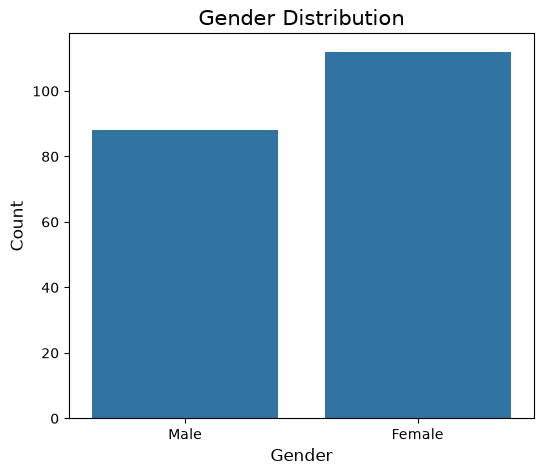

In [10]:
plt.figure(figsize=(6,5))

sns.countplot(x='Gender',data=df)
plt.title('Gender Distribution',fontsize=15)
plt.xlabel('Gender',fontsize=12)
plt.ylabel('Count',fontsize=12) 

plt.show()


### Observation

- Customer annual income is distributed across low, medium, and high income groups.
- Most customers fall into the medium income range.
- Income varies significantly among customers.

## Spending Score Distribution

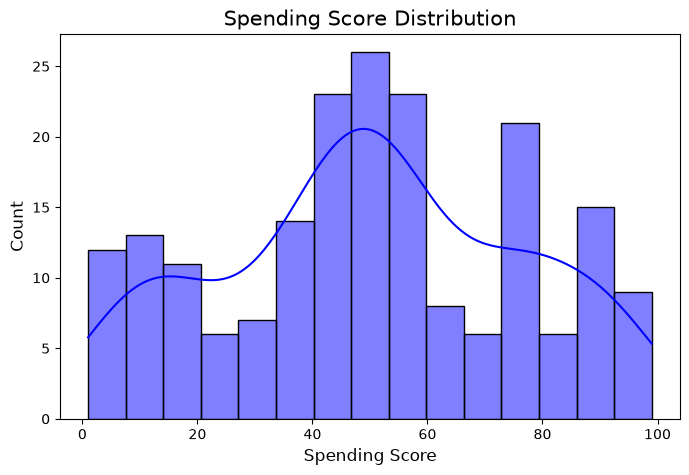

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(df["Spending Score (1-100)"],bins=15,kde=True,color='blue')

plt.title('Spending Score Distribution',fontsize=15)
plt.xlabel('Spending Score',fontsize=12)
plt.ylabel('Count',fontsize=12)
plt.show()  

### Observation

- Spending scores are spread across the entire range.
- The dataset contains both low-spending and high-spending customers.
- Customer spending behavior is highly diverse.

## Correlation Heatmap

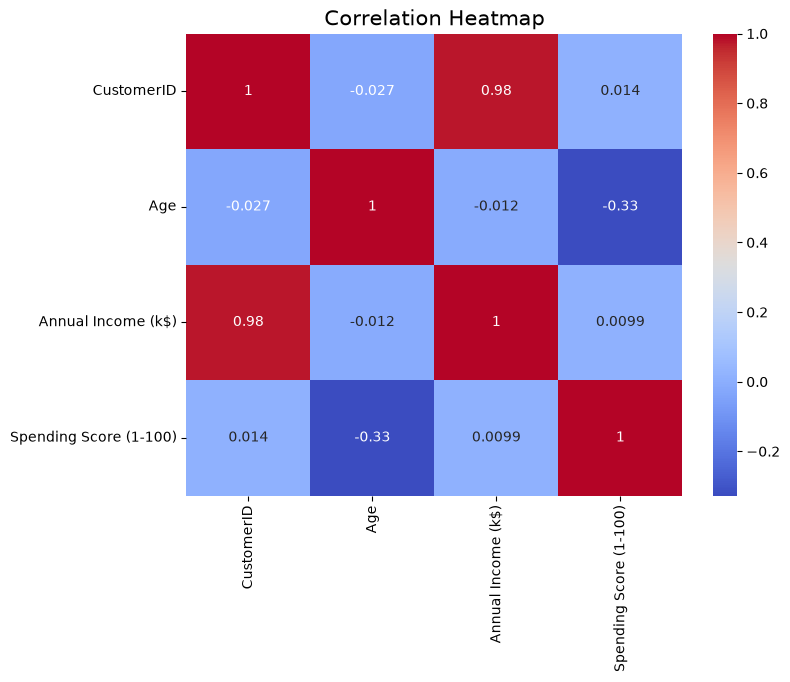

In [20]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap",fontsize=15 )

plt.show()

### Observation

- Most numerical features show weak correlations.
- Age and Spending Score have a slight negative relationship.
- Annual Income has little correlation with Spending Score.
- Customer segmentation requires clustering instead of relying only on correlations.

## K-Means Clutering

Chosesing the Coulumn What We Can want

In [11]:
x=df[["Annual Income (k$)","Spending Score (1-100)"]]

x.head(6)

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
5,17,76


after Loading Data We Preapare for Clutering

In [12]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

Plot the Ellbow Ghraph 

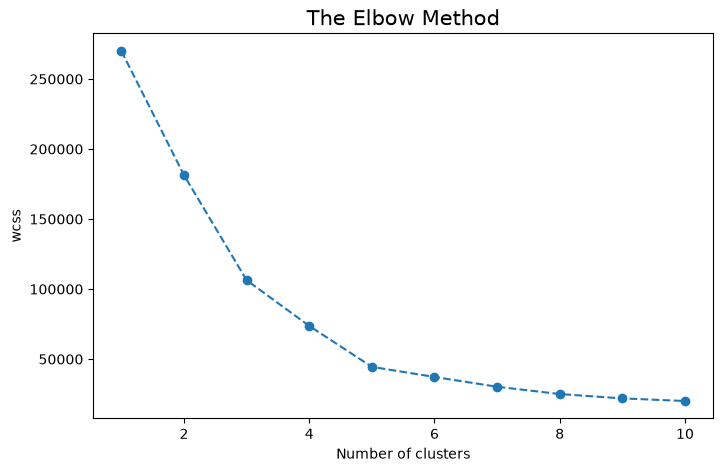

In [40]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss,marker='o',linestyle='--')
plt.title('The Elbow Method',fontsize=15)       
plt.xlabel("Number of clusters")
plt.ylabel("wcss")

plt.show()


### Observation

- The elbow point appears around **5 clusters**.
- Choosing 5 clusters provides a good balance between accuracy and simplicity.
- Therefore, K = 5 is selected for customer segmentation.

In [13]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

y_kmeans = kmeans.fit_predict(x)

df["Cluster"] = y_kmeans

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


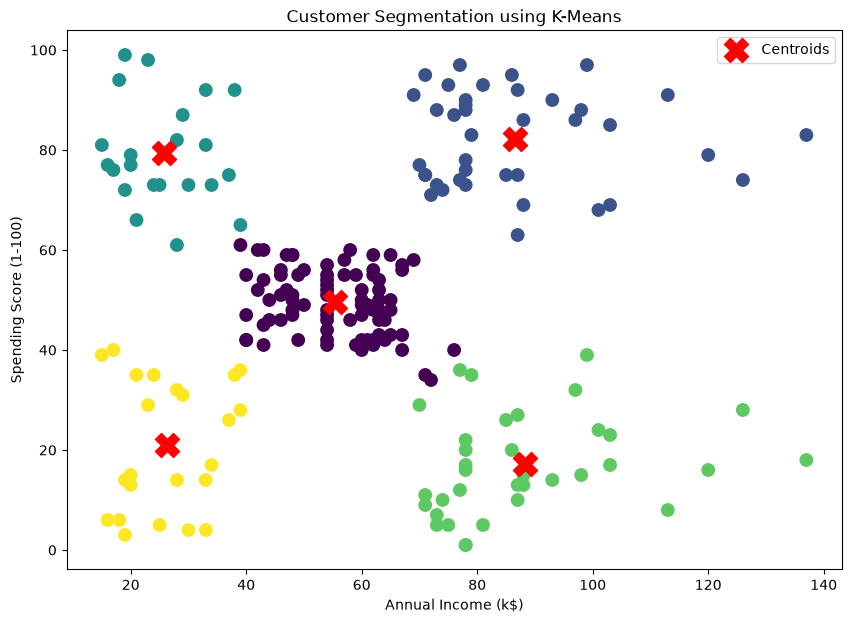

In [15]:
plt.figure(figsize=(10,7))

plt.scatter(
    x.iloc[:, 0],
    x.iloc[:, 1],
    c=df["Cluster"],
    cmap="viridis",
    s=80
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=300,
    c="red",
    marker="X",
    label="Centroids"
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()

plt.show()

In [16]:
df.groupby("Cluster").mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,86.320988,42.716049,55.296296,49.518519
1,162.000000,32.692308,86.538462,82.128205
2,23.090909,25.272727,25.727273,79.363636
3,164.371429,41.114286,88.200000,17.114286
4,23.000000,45.217391,26.304348,20.913043


## Business Insights

- Cluster 0: Customers with moderate income and moderate spending.
- Cluster 1: High-income customers with high spending behavior (Premium Customers).
- Cluster 2: Low-income customers with low spending behavior.
- Cluster 3: High-income customers with low spending behavior (Potential Marketing Target).
- Cluster 4: Low-income customers with high spending behavior.

## Conclusion

Customer segmentation using the K-Means algorithm successfully grouped customers based on their Annual Income and Spending Score. These insights can help businesses create targeted marketing campaigns, improve customer retention, and design personalized offers for different customer groups.